In [1]:
# illustrative example of use VeraRubin 

## Creating a Local Butler for a Selected Set of Visits

> Version: 1.0
> Container Size: Large

> Description: In this notebook, we present illustrative examples of using Vera Rubin’s functions to create a local Butler for a chosen set of visits.

In [1]:
# Complementary info
! echo $IMAGE_DESCRIPTION
! eups list -s | grep lsst_distrib

Release r29.2.0 (RSP Build 2648)
lsst_distrib          gc675d380bf+f75de59d28 	current v29_2_0 v29_2_0_rc1 setup


In [2]:
%load_ext autoreload
%autoreload

In [3]:
import numpy as np
import VeraRubin as vr
import matplotlib.pyplot as plt

from lsst.daf.butler import Butler

### Loading the butler and show some information

In [4]:
# Initialize Butler
COLLECTION = "LSSTComCam/DP1"
REPOSITORY = "dp1"

butler = Butler(config=REPOSITORY, collections=COLLECTION)
assert butler is not None

REMOTE_REPO = vr.get_butler_location(butler)  # Remote butler repo path
print('Remote butler repo path: ', REMOTE_REPO)

Remote butler repo path:  https://data.lsst.cloud/api/butler/repo/dp1/


In [6]:
registry = butler.registry
dt_list = registry.queryDatasetTypes()  # datasetTypes
dt_collections = registry.queryCollections()  # collections

In [7]:
# Base Collection we want to used

collection_targets = [t.lower() for t in ["LSSTComCam/DP1", "skymaps", "LSSTComCam/raw"]]

print(f'Found {len(dt_collections)} Collections \n')
grouped_collections = {key: [] for key in collection_targets} # Dictionary to store matches grouped by category

for dt in dt_collections:
    name = dt.lower()
    for collection in collection_targets:
        if collection in name:
            grouped_collections[collection].append(dt)

# Display grouped results
print("Related Collections by Category \n")

for collection in collection_targets:
    print(f"Category: {collection}")
    if grouped_collections[collection]:
        for item in sorted(grouped_collections[collection]):
            print(f"  - {item}")
    else:
        print("  (none found)")
    print()

Found 95 Collections 

Related Collections by Category 

Category: lsstcomcam/dp1
  - LSSTComCam/DP1
  - LSSTComCam/DP1/v1
  - LSSTComCam/DP1/v2

Category: skymaps
  - skymaps

Category: lsstcomcam/raw
  - LSSTComCam/raw/DP1-RC2/DM-49594
  - LSSTComCam/raw/all



In [8]:
# Base datasetTypes we want to search

base_targets = [t.lower() for t in ["visit_image", "deep_coadd", "deepcoadd", "raw", "Warp"]]

print(f'Found {len(dt_list)} DatasetTypes \n')
grouped = {key: [] for key in base_targets}

for dt in dt_list:  # Scan through all datasetTypes
    name = dt.name.lower()
    for base in base_targets:  # Check if the datasetType name contains any of the base targets
        if base in name:
            grouped[base].append(dt.name)

print("Related DatasetTypes by Category \n")
for base in base_targets:
    print(f"Category: {base}")
    if grouped[base]:
        for item in sorted(grouped[base]):
            print(f"  - {item}")
    else:
        print("  (none found)")
    print()

Found 592 DatasetTypes 

Related DatasetTypes by Category 

Category: visit_image
  - visit_image
  - visit_image_background

Category: deep_coadd
  - deep_coadd
  - deep_coadd_background
  - deep_coadd_n_image

Category: deepcoadd
  - assembleDeepCoadd_config
  - assembleDeepCoadd_gatherResourceUsage_config
  - assembleDeepCoadd_gatherResourceUsage_log
  - assembleDeepCoadd_gatherResourceUsage_metadata
  - assembleDeepCoadd_log
  - assembleDeepCoadd_metadata
  - deepCoadd_dcr_ddec_consolidated_map_weighted_mean
  - deepCoadd_dcr_dra_consolidated_map_weighted_mean
  - deepCoadd_dcr_e1_consolidated_map_weighted_mean
  - deepCoadd_dcr_e2_consolidated_map_weighted_mean
  - deepCoadd_epoch_consolidated_map_max
  - deepCoadd_epoch_consolidated_map_mean
  - deepCoadd_epoch_consolidated_map_min
  - deepCoadd_exposure_time_consolidated_map_sum
  - deepCoadd_psf_e1_consolidated_map_weighted_mean
  - deepCoadd_psf_e2_consolidated_map_weighted_mean
  - deepCoadd_psf_maglim_consolidated_map_weight

## Identify visit images around location

In [10]:
# Identify visit images around location
ra_deg, dec_deg = (53.2, -27.8)
loc_data = ra_deg, dec_deg

bands = ['u', 'i']

visit_name = "visit_image"
print(f"Using -> {visit_name}")

visits_image_selected_list = {}
for band in bands:
    visit_refs = vr.visit_dataset(butler, band, loc_data, use_patch_area=False, detectors=None, timespan=None, visit_ids=None)
    print(f'[INF] Found {len(visit_refs)} visits in band {band}')
    visits_image_selected_list[band] = visit_refs  # Saving the visit data set per band

Using -> visit_image
[INF] Found 31 visits in band u
[INF] Found 114 visits in band i


In [11]:
# Data example
print(visits_image_selected_list['u'][0].dataId) # datasetType dimensions run dataId
print(visits_image_selected_list['u'][1].dataId) # datasetType dimensions run dataId

{instrument: 'LSSTComCam', detector: 2, visit: 2024110900195, band: 'u', day_obs: 20241109, physical_filter: 'u_02'}
{instrument: 'LSSTComCam', detector: 5, visit: 2024110900198, band: 'u', day_obs: 20241109, physical_filter: 'u_02'}


## Creating the local butler repository and copying the visits

In [7]:
# General CONFIGURATION
LOCAL_REPO = "./local_butler"       # Local butler repo path
REMOTE_REPO = vr.get_butler_location(butler)  # Remote butler repo path

In [13]:
# taking the first four
nbest = 6

visits_u = visits_image_selected_list['u'][:nbest]
visits_i = visits_image_selected_list['i'][:nbest]

In [14]:
# Make the object/Setup logging directory and logger
##############

lbutler = vr.LocalButler(local_repo=LOCAL_REPO, remote_repo=REMOTE_REPO, LOGDIR="/logs")

2026-03-03 04:43:31 [INFO] Created LOGDIR at ./local_butler/logs


2026-03-03 04:43:31 [INFO] Starting pipeline for local repo: ./local_butler


In [15]:
# Creating an empty butler
##############

lbutler.make_repo()

2026-03-03 04:43:36 [INFO] Creating Butler repo at ./local_butler


In [16]:
# Register instruments (collect unique instrument names from DatasetRefs)
##############

lbutler.reg_instruments(visits_u, remote_collection=COLLECTION)

2026-03-03 04:43:37 [INFO] Registering instruments: ['LSSTComCam']


2026-03-03 04:43:37 [INFO] Detected instruments to register: ['LSSTComCam']


2026-03-03 04:43:37 [INFO] Opening remote Butler: https://data.lsst.cloud/api/butler/repo/dp1/ (collections=LSSTComCam/DP1)


2026-03-03 04:43:37 [INFO] [CMD] butler register-instrument ./local_butler lsst.obs.lsst.LsstComCam


2026-03-03 04:43:44 [INFO] 


2026-03-03 04:43:44 [INFO] Registered instrument 'LSSTComCam' -> lsst.obs.lsst.LsstComCam


2026-03-03 04:43:44 [INFO] Instrument registration complete.


In [17]:
# Registering SkyMap DatasetType and copying skyMap dataset(s) (preserving UUIDs)
##############

lbutler.reg_transfer_skyMap(remote_collection=COLLECTION)

2026-03-03 04:43:44 [INFO] Registering DatasetType 'skyMap' in local repo before transfer.


2026-03-03 04:43:45 [INFO] Registered DatasetType: skyMap


2026-03-03 04:43:45 [INFO] Copying skyMap(s) from remote to local (preserving UUIDs)...


2026-03-03 04:43:45 [INFO] [SKYMAP] SkyMap dimension found: lsst_cells_v1


2026-03-03 04:43:48 [INFO] [SKYMAP] Found skyMap dataset in collection: skymaps


2026-03-03 04:43:48 [INFO] [CMD] butler transfer-datasets https://data.lsst.cloud/api/butler/repo/dp1/ ./local_butler --dataset-type skyMap --collections LSSTComCam/DP1 --where skymap='lsst_cells_v1' --transfer-dimensions


Number of datasets transferred: 1
2026-03-03 04:43:55 [INFO] [SKYMAP] SkyMap successfully transferred.


2026-03-03 04:43:55 [INFO] SkyMap copy finished.


#### We are ready to transfer some datasets associated to "visit_image"

In [18]:
# First u

lbutler.discover_transfer_datasets(visits_u, remote_collection=COLLECTION)

2026-03-03 04:44:58 [INFO] Starting recompilation of some Datas


2026-03-03 04:44:59 [INFO] Getting the remote Butler registry on: https://data.lsst.cloud/api/butler/repo/dp1/.


2026-03-03 04:44:59 [INFO]   Required present : ['deep_coadd', 'visit_image', 'visit_summary']


2026-03-03 04:44:59 [INFO]   Missing required : ['visit_summary_metadata', 'visit_summary_schema']


2026-03-03 04:44:59 [INFO] Starting registering DatasetTypes


...

2026-03-03 04:46:01 [INFO] [CMD] butler transfer-datasets https://data.lsst.cloud/api/butler/repo/dp1/ ./local_butler --where instrument='LSSTComCam' AND visit IN (2024110900203) AND band='u' --collections LSSTComCam/DP1 --dataset-type visit_summary,visit_image,deep_coadd


2026-03-03 04:46:13 [INFO] Number of datasets transferred: 49


2026-03-03 04:46:13 [WARNING] lsst.daf.butler.direct_butler._direct_butler INFO: Importing 49 datasets into Butler(collections=DirectButlerCollections(defaults=()), run=None, datastore='file:///home/arestrada88/Alma_proyect/local_butler/', registry='SQLite3@/home/arestrada88/Alma_proyect/local_butler/gen3.sqlite3')
lsst.daf.butler.datastores.fileDatastore INFO: Skipped transfer of 37 datasets already present in datastore


2026-03-03 04:46:13 [INFO] Completed transfer-datasets for dataset=['visit_summary', 'visit_image', 'deep_coadd'], visits=(2024110900203)


2026-03-03 04:46:13 [INFO] Transfer succeeded for dataId: {instrument: 'LSSTComCam', detector: 2, visit: 2024110900203, band: 'u', day_obs: 20241109, physical_filter: 'u_02'}


In [19]:
# Now i

lbutler.discover_transfer_datasets(visits_i, remote_collection=COLLECTION)

2026-03-03 04:46:13 [INFO] Starting recompilation of some Datas


2026-03-03 04:46:13 [INFO] Getting the remote Butler registry on: https://data.lsst.cloud/api/butler/repo/dp1/.


2026-03-03 04:46:13 [INFO]   Required present : ['deep_coadd', 'visit_image', 'visit_summary']


2026-03-03 04:46:13 [INFO]   Missing required : ['visit_summary_metadata', 'visit_summary_schema']


2026-03-03 04:46:13 [INFO] Starting registering DatasetTypes


...

2026-03-03 04:47:18 [INFO] [CMD] butler transfer-datasets https://data.lsst.cloud/api/butler/repo/dp1/ ./local_butler --where instrument='LSSTComCam' AND visit IN (2024110800257) AND band='i' --collections LSSTComCam/DP1 --dataset-type visit_summary,visit_image,deep_coadd


2026-03-03 04:47:29 [INFO] Number of datasets transferred: 48


2026-03-03 04:47:29 [WARNING] lsst.daf.butler.direct_butler._direct_butler INFO: Importing 48 datasets into Butler(collections=DirectButlerCollections(defaults=()), run=None, datastore='file:///home/arestrada88/Alma_proyect/local_butler/', registry='SQLite3@/home/arestrada88/Alma_proyect/local_butler/gen3.sqlite3')
lsst.daf.butler.datastores.fileDatastore INFO: Skipped transfer of 33 datasets already present in datastore


2026-03-03 04:47:29 [INFO] Completed transfer-datasets for dataset=['visit_summary', 'visit_image', 'deep_coadd'], visits=(2024110800257)


2026-03-03 04:47:29 [INFO] Transfer succeeded for dataId: {instrument: 'LSSTComCam', detector: 8, visit: 2024110800257, band: 'i', day_obs: 20241108, physical_filter: 'i_06'}


In [20]:
# Finally, create a chained collection

lbutler.chained(chain_name="local_main_chain")

2026-03-03 04:47:29 [INFO] Making a chained collection


2026-03-03 04:47:30 [INFO] Creating chained collection 'local_main_chain' with members: ['skymaps', 'skymaps', 'LSSTComCam/runs/DRP/DP1/DM-51335', 'LSSTComCam/runs/DRP/DP1/DM-53601', 'LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z']


2026-03-03 04:47:30 [INFO] Registered CHAINED collection: local_main_chain


2026-03-03 04:47:30 [INFO] Set chain for 'local_main_chain' -> ['skymaps', 'skymaps', 'LSSTComCam/runs/DRP/DP1/DM-51335', 'LSSTComCam/runs/DRP/DP1/DM-53601', 'LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z']


## Visualizing some butler-information

In [21]:
del lbutler

In [22]:
lbutler = Butler(LOCAL_REPO)

In [23]:
print("List of avalibles colections:")
# Collections
!butler query-collections --chains 'TREE' $LOCAL_REPO

List of avalibles colections:
                            Name                              Type 
----------------------------------------------------------- -------
LSSTComCam/runs/DRP/DP1/DM-51335                            RUN    
LSSTComCam/runs/DRP/DP1/DM-53601                            RUN    
LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z   RUN    
local_main_chain                                            CHAINED
  skymaps                                                   RUN    
  LSSTComCam/runs/DRP/DP1/DM-51335                          RUN    
  LSSTComCam/runs/DRP/DP1/DM-53601                          RUN    
  LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z RUN    
skymaps                                                     RUN    


In [24]:
# Dataset types
print("List of avalibles datasetType:")
!butler query-dataset-types --verbose $LOCAL_REPO

List of avalibles datasetType:
     name                                     dimensions                                 storage class 
------------- ------------------------------------------------------------------------- ---------------
deep_coadd    ['band', 'skymap', 'tract', 'patch']                                      ExposureF      
skyMap        ['skymap']                                                                SkyMap         
visit_image   ['band', 'instrument', 'day_obs', 'detector', 'physical_filter', 'visit'] ExposureF      
visit_summary ['band', 'instrument', 'day_obs', 'physical_filter', 'visit']             ExposureCatalog


In [25]:
# Skymap collection
print("List of avalibles Skymaps:")
!butler query-datasets $LOCAL_REPO skyMap --collections skymaps

List of avalibles Skymaps:

 type    run                    id                      skymap   
------ ------- ------------------------------------ -------------
skyMap skymaps 64c16b0a-0a1a-4f78-81e5-f49a9328c388 lsst_cells_v1



In [26]:
# Tract
print("List of avalibles Tract:")
!butler query-dimension-records $LOCAL_REPO 'tract'

List of avalibles Tract:
    skymap     id   region 
------------- ---- --------
lsst_cells_v1 4848 (elided)
lsst_cells_v1 4849 (elided)
lsst_cells_v1 5063 (elided)
lsst_cells_v1 5064 (elided)


In [27]:
# Skymap records

!butler query-dimension-records $LOCAL_REPO 'skymap'

     name                        hash                    tract_max patch_nx_max patch_ny_max
------------- ------------------------------------------ --------- ------------ ------------
lsst_cells_v1 0xe2736e41244df00bbdb93aecac0ae4b2d19dda91     18938           10           10


In [28]:
# Datasets
!butler query-datasets $LOCAL_REPO visit_image \
  --collections local_main_chain \
  --limit 5


    type                  run                                 id                  instrument detector     visit     band day_obs  physical_filter
----------- -------------------------------- ------------------------------------ ---------- -------- ------------- ---- -------- ---------------
visit_image LSSTComCam/runs/DRP/DP1/DM-53601 019b1942-03f7-707a-944c-780607a2a536 LSSTComCam        0 2024110900195    u 20241109            u_02
visit_image LSSTComCam/runs/DRP/DP1/DM-53601 019b1973-ee28-7201-83d1-432420009ac5 LSSTComCam        3 2024110900195    u 20241109            u_02
visit_image LSSTComCam/runs/DRP/DP1/DM-53601 019b1994-761b-71c1-835a-33de156b1dcd LSSTComCam        5 2024110900195    u 20241109            u_02
visit_image LSSTComCam/runs/DRP/DP1/DM-53601 019b19a4-ca7d-73f8-a102-57c9d581a2b3 LSSTComCam        6 2024110900195    u 20241109            u_02
visit_image LSSTComCam/runs/DRP/DP1/DM-53601 019b19c6-aa91-72ae-81a2-19b9008af39c LSSTComCam        8 2024110900195    u 20

Notice that when we make the local butler, we used 4 visit_image; however, we have more than four. This is because the **discover_transfer_datasets** routine transfer all detector, and the dataset types:

>>
 REQUIRED_TYPES: {
        "visit_image", "visit_summary", "visit_summary_schema", "visit_summary_metadata",
        "deep_coadd",
    }

In [29]:
# Detector dimension records
!butler query-dimension-records $LOCAL_REPO 'detector'

instrument  id full_name name_in_raft raft purpose
---------- --- --------- ------------ ---- -------
LSSTComCam   0   R22_S00          S00  R22 SCIENCE
LSSTComCam   1   R22_S01          S01  R22 SCIENCE
LSSTComCam   2   R22_S02          S02  R22 SCIENCE
LSSTComCam   3   R22_S10          S10  R22 SCIENCE
LSSTComCam   4   R22_S11          S11  R22 SCIENCE
LSSTComCam   5   R22_S12          S12  R22 SCIENCE
LSSTComCam   6   R22_S20          S20  R22 SCIENCE
LSSTComCam   7   R22_S21          S21  R22 SCIENCE
LSSTComCam   8   R22_S22          S22  R22 SCIENCE


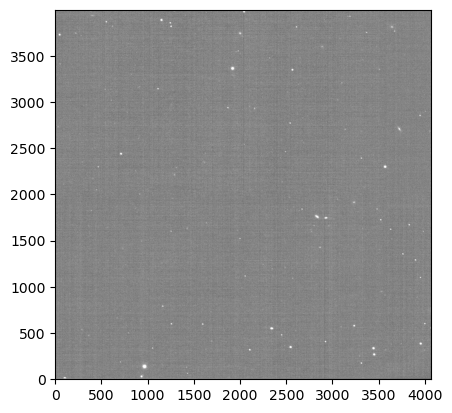

In [30]:
# Visualizing 

img = lbutler.get('visit_image', dataId=visits_u[0].dataId, 
                  collections="local_main_chain").getImage().getArray()

p5, p95 = np.nanpercentile(img, [0.01, 99.9])
plt.imshow(img, origin='lower', cmap='gray', vmin=p5, vmax=p95)

## Add extra visits.

Now, in the case that we have previously local butler, we can add extra visits

In [31]:
del lbutler

In [32]:
lbutler = vr.LocalButler(local_repo=LOCAL_REPO, remote_repo=REMOTE_REPO, LOGDIR="/logs")

2026-03-03 04:48:20 [INFO] Created LOGDIR at ./local_butler/logs


2026-03-03 04:48:20 [INFO] Starting pipeline for local repo: ./local_butler


In [33]:
visits_u = visits_image_selected_list['u'][-3:-1]


lbutler.discover_transfer_datasets(visits_u, remote_collection=COLLECTION)

2026-03-03 04:48:20 [INFO] Starting recompilation of some Datas


2026-03-03 04:48:20 [INFO] Getting the remote Butler registry on: https://data.lsst.cloud/api/butler/repo/dp1/.


2026-03-03 04:48:20 [INFO]   Required present : ['deep_coadd', 'visit_image', 'visit_summary']


2026-03-03 04:48:20 [INFO]   Missing required : ['visit_summary_metadata', 'visit_summary_schema']


2026-03-03 04:48:20 [INFO] Starting registering DatasetTypes


...

2026-03-03 04:48:31 [INFO] [CMD] butler transfer-datasets https://data.lsst.cloud/api/butler/repo/dp1/ ./local_butler --where instrument='LSSTComCam' AND visit IN (2024120100188) AND band='u' --collections LSSTComCam/DP1 --dataset-type visit_summary,visit_image,deep_coadd


2026-03-03 04:48:41 [INFO] Number of datasets transferred: 51


2026-03-03 04:48:41 [WARNING] lsst.daf.butler.direct_butler._direct_butler INFO: Importing 51 datasets into Butler(collections=DirectButlerCollections(defaults=()), run=None, datastore='file:///home/arestrada88/Alma_proyect/local_butler/', registry='SQLite3@/home/arestrada88/Alma_proyect/local_butler/gen3.sqlite3')
lsst.daf.butler.datastores.fileDatastore INFO: Skipped transfer of 37 datasets already present in datastore


2026-03-03 04:48:41 [INFO] Completed transfer-datasets for dataset=['visit_summary', 'visit_image', 'deep_coadd'], visits=(2024120100188)


2026-03-03 04:48:41 [INFO] Transfer succeeded for dataId: {instrument: 'LSSTComCam', detector: 3, visit: 2024120100188, band: 'u', day_obs: 20241201, physical_filter: 'u_02'}


{instrument: 'LSSTComCam', detector: 3, visit: 2024120100188, band: 'u', day_obs: 20241201, physical_filter: 'u_02'}


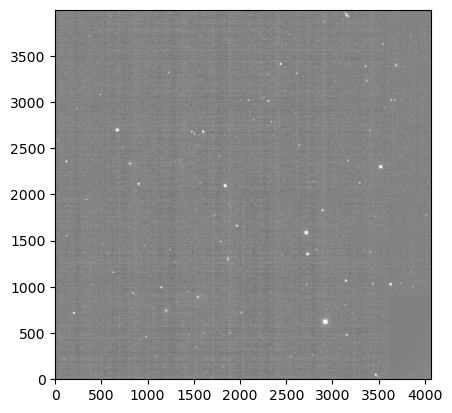

In [34]:
# Checking
loc_butler = Butler(LOCAL_REPO)

print(visits_u[-1].dataId)

img = loc_butler.get('visit_image', dataId=visits_u[-1].dataId, 
                  collections="local_main_chain").getImage().getArray()

p5, p95 = np.nanpercentile(img, [0.01, 99.9])
plt.imshow(img, origin='lower', cmap='gray', vmin=p5, vmax=p95)

In [13]:
# Validating
!butler query-datasets $LOCAL_REPO visit_image \
  --collections local_main_chain \
  --where "instrument='LSSTComCam' AND detector=0"
  #--limit 5


    type                  run                                 id                  instrument detector     visit     band day_obs  physical_filter
----------- -------------------------------- ------------------------------------ ---------- -------- ------------- ---- -------- ---------------
visit_image LSSTComCam/runs/DRP/DP1/DM-53601 019b1941-8acf-7980-8487-d82d7c24a5af LSSTComCam        0 2024110800245    i 20241108            i_06
visit_image LSSTComCam/runs/DRP/DP1/DM-53601 019b1941-8ad4-7363-807e-6a22f54d3663 LSSTComCam        0 2024110800248    i 20241108            i_06
visit_image LSSTComCam/runs/DRP/DP1/DM-53601 019b1941-8ad1-74e2-94cd-5a4773eab36e LSSTComCam        0 2024110800249    i 20241108            i_06
visit_image LSSTComCam/runs/DRP/DP1/DM-53601 019b1941-8acf-7e45-bf17-1e45730a45d5 LSSTComCam        0 2024110800252    i 20241108            i_06
visit_image LSSTComCam/runs/DRP/DP1/DM-53601 019b1941-8ae0-7b8c-9c25-0d845ba6b46a LSSTComCam        0 2024110800256    i 20